# 5.CIFAR-10 图像分类模型

本章使用 PyTorch 在经典基准数据集 **CIFAR-10** 上构建并训练卷积神经网络，完成对飞机、汽车、鸟类等十类物体的图像分类任务，系统掌握完整的深度学习图像分类实验流程。

**主要内容：**
- CIFAR-10 数据集介绍与加载
- 卷积神经网络架构设计
- 数据增强与正则化策略
- 模型训练、验证与评估
- 使用 TensorBoard 可视化训练过程

## 一、导入依赖库

导入本项目所需的全部 Python 库，包括绘图、数值计算、深度学习框架及进度条工具。

In [1]:
import matplotlib as mpl  # 导入 matplotlib 绘图库，mpl 为别名
import matplotlib.pyplot as plt  # 导入 pyplot 子模块，提供类 MATLAB 的绘图接口
%matplotlib inline  
# Jupyter 魔法命令：将图表内嵌显示在 notebook 输出区域
import numpy as np  # 导入 NumPy 数值计算库，别名 np
import sklearn  # 导入 scikit-learn 机器学习库（此处用于评估指标）
import pandas as pd  # 导入 Pandas 数据分析库，别名 pd
import os  # 导入 os 模块，用于操作系统接口（目录创建、路径拼接等）
import sys  # 导入 sys 模块，用于访问 Python 解释器信息
import time  # 导入 time 模块，用于计时
from tqdm import tqdm  # 从 tqdm 导入进度条组件，auto 模式可自动适配终端/Jupyter
import torch  # 导入 PyTorch 深度学习框架
import torch.nn as nn  # 导入 PyTorch 神经网络模块，别名 nn
import torch.nn.functional as F  # 导入 PyTorch 函数式接口（含激活函数等），别名 F

print(sys.version_info)  # 打印当前 Python 版本信息
for module in mpl, np, pd, sklearn, torch:  # 遍历主要依赖库
    print(module.__name__, module.__version__)  # 打印各库名称及其版本号
    
# 若 CUDA GPU 可用则使用第 0 块 GPU，否则回退到 CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)  # 打印当前使用的计算设备（cuda:0 或 cpu）

seed = 42  # 全局随机种子，确保实验可复现

sys.version_info(major=3, minor=14, micro=5, releaselevel='final', serial=0)
matplotlib 3.10.9
numpy 2.4.6
pandas 3.0.3
sklearn 1.9.0
torch 2.12.0+cu132
cuda:0


## 二、数据准备

本节完成 CIFAR-10 数据集的路径配置、CSV 解析、数据集划分、自定义 Dataset 构建及数据增强管道设置。

```
cifar-10
├── sampleSubmission.csv
├── test
├── train
└── trainLabels.csv
```

### 2.1 路径配置与 CSV 解析

定义数据集目录路径、类别列表，并实现 `parse_csv_file` 函数将 CSV 文件解析为 `(图片路径, 类别标签)` 列表。

In [2]:
from pathlib import Path  # 导入 pathlib.Path，用于面向对象的跨平台路径操作

DATA_DIR = Path("data/cifar-10")  # CIFAR-10 数据集根目录（Path 类型）

train_lables_file = DATA_DIR / "trainLabels.csv"  # 训练集标签 CSV 文件路径
test_csv_file = DATA_DIR / "sampleSubmission.csv"  # 测试集提交模板 CSV 文件路径
train_folder = DATA_DIR / "train"  # 训练集图片所在目录
test_folder = DATA_DIR / "test"  # 测试集图片所在目录

# CIFAR-10 共 10 个类别，按字母顺序排列
class_names = [
    'airplane',    # 类别 0：飞机
    'automobile',  # 类别 1：汽车
    'bird',        # 类别 2：鸟
    'cat',         # 类别 3：猫
    'deer',        # 类别 4：鹿
    'dog',         # 类别 5：狗
    'frog',        # 类别 6：青蛙
    'horse',       # 类别 7：马
    'ship',        # 类别 8：船
    'truck',       # 类别 9：卡车
]

def parse_csv_file(filepath, folder):
    """
    解析 CSV 文件，将其转换为 (图片完整路径, 类别标签) 的列表。

    参数:
        filepath (Path): CSV 文件路径，文件首行为列名（自动跳过）
        folder   (Path): 图片所在目录
    返回:
        list of (Path, str): 每个元素为 (图片完整路径, 类别标签字符串)
    """
    results = []  # 初始化结果列表
    # 打开 CSV 文件，读取全部行
    with open(filepath, 'r') as f:
        lines = f.readlines()[1:]  # 跳过首行（表头），从第二行起读取数据
    for line in lines:  # 遍历每一行
        image_id, label_str = line.strip('\n').split(',')  # 去换行符后按逗号分割，得到图片 ID 与类别
        image_full_path = folder / f"{image_id}.png"  # 拼接图片完整路径
        results.append((image_full_path, label_str))  # 将 (路径, 标签) 元组追加到结果列表
    return results  # 返回 (路径, 标签) 元组列表

# 分别解析训练集和测试集 CSV 文件
train_labels_info = parse_csv_file(train_lables_file, train_folder)
test_csv_info = parse_csv_file(test_csv_file, test_folder)
# 格式化打印前 5 条记录，验证解析结果是否正确
import pprint
pprint.pprint(train_labels_info[0:5])
pprint.pprint(test_csv_info[0:5])
print(len(train_labels_info), len(test_csv_info))  # 打印训练集与测试集样本总数

[(WindowsPath('data/cifar-10/train/1.png'), 'frog'),
 (WindowsPath('data/cifar-10/train/2.png'), 'truck'),
 (WindowsPath('data/cifar-10/train/3.png'), 'truck'),
 (WindowsPath('data/cifar-10/train/4.png'), 'deer'),
 (WindowsPath('data/cifar-10/train/5.png'), 'automobile')]
[(WindowsPath('data/cifar-10/test/1.png'), 'cat'),
 (WindowsPath('data/cifar-10/test/2.png'), 'cat'),
 (WindowsPath('data/cifar-10/test/3.png'), 'cat'),
 (WindowsPath('data/cifar-10/test/4.png'), 'cat'),
 (WindowsPath('data/cifar-10/test/5.png'), 'cat')]
50000 300000


### 2.2 划分训练集、验证集与测试集

将 50000 条训练数据按 **分层抽样（Stratified Sampling）** 方式划分为训练集（45000 条）与验证集（5000 条），确保每个类别在两个子集中的比例与原始分布完全一致（每类各 500 条进入验证集），并将三个子集分别整理为 Pandas DataFrame。

In [3]:
from sklearn.model_selection import train_test_split  # 导入 sklearn 的数据集划分工具，支持分层抽样

# -----------------------------------------------------------------------
# 为什么元组列表（list of tuples）能直接转为 DataFrame？
#
# parse_csv_file 返回的 train_labels_info 结构如下：
#   [ (Path('.../1.png'), 'frog'), (Path('.../2.png'), 'truck'), ... ]
# 即每个元素是一个二元组 (图片路径, 类别标签)。
#
# pd.DataFrame() 接受任何"规整的二维可迭代对象"作为输入：
#   - 外层列表 → 行（每个元素对应一行）
#   - 内层元组 → 列（元组中每个元素对应一列的值）
# 元组与列表在此等价，pandas 只要求内层元素"可迭代且长度固定"即可。
#
# 由于元组没有 key（不像 dict），pandas 无法自动推断列名，
# 可在构造时通过 columns 参数直接指定，避免事后重命名。
# -----------------------------------------------------------------------

# 将全量 50000 条训练数据转为 DataFrame，同时指定列名
all_train_df = pd.DataFrame(train_labels_info, columns=['filepath', 'class'])
# all_train_df：shape=(50000, 2)；columns: filepath(图片路径), class(类别标签字符串)

# -----------------------------------------------------------------------
# 分层抽样（Stratified Sampling）原理
#
# CIFAR-10 共 10 个类别，每类恰好 5000 张图像，类别完全均衡。
# 若直接按顺序切片（前 45000 / 后 5000），某些类别可能在验证集中
# 过多或过少，导致验证指标失真。
#
# train_test_split 的 stratify 参数：
#   - 接受与样本行对应的类别序列（Series 或数组）
#   - 内部按类别分组，各组独立随机抽取 test_size 比例的样本
#   - 保证训练集与验证集中每个类别的比例 ≈ 原始分布
#
# 本例：50000 条 → 验证集 5000 条（每类 500 条），训练集 45000 条（每类 4500 条）
# -----------------------------------------------------------------------
train_df, valid_df = train_test_split(
    all_train_df,                    # 待划分的全量 DataFrame（50000 行）
    test_size=5000,                  # 验证集绝对大小：5000 条（也可传 0.1 表示 10%）
    stratify=all_train_df['class'],  # 按 class 列分层，确保各类样本比例一致
    random_state=seed                # 固定随机种子（seed=42），保证实验可复现
)
# train_df：45000 行，每类 4500 条；valid_df：5000 行，每类 500 条

# -----------------------------------------------------------------------
# 为什么需要 reset_index(drop=True)？
#
# train_test_split 对原 DataFrame 做随机打乱后抽样，子集中每行仍保留
# 其在 all_train_df 中的原始行号（索引），例如验证集可能是：
#
#        filepath            class
#  312   .../313.png         frog    ← 原来第 312 行
#  8901  .../8902.png        cat     ← 原来第 8901 行
#  ...
#
# 此时索引不连续、不从 0 开始。若直接调用 reset_index()（不带 drop=True），
# pandas 会将旧索引（312、8901…）移入一个名为 "index" 的新列，污染数据。
# 加上 drop=True 则直接丢弃旧索引，生成新的 0, 1, 2, ... 连续序号。
#
# 重置的意义：后续 Dataset.__getitem__(idx) 通常用 df.iloc[idx] 按位置取行，
# 连续索引能保证 idx 与行位置严格对应，逻辑清晰且不易出错。
# -----------------------------------------------------------------------
train_df = train_df.reset_index(drop=True)  # 训练集行索引重置为 0~44999
valid_df = valid_df.reset_index(drop=True)  # 验证集行索引重置为 0~4999

# 构建测试集 DataFrame，在构造时直接指定列名
test_df = pd.DataFrame(test_csv_info, columns=['filepath', 'class'])
# test_df：300000 行（测试集样本），columns: filepath(图片路径), class(占位标签)

# 验证分层效果：打印验证集中各类别的样本数量，理论上每类应恰好 500 条
print("验证集各类别样本数（分层抽样结果）：")
print(valid_df['class'].value_counts().sort_index())  # 按类别字母序排列打印

print("\n训练集前 5 行：")
print(train_df.head())  # 打印训练集前 5 行，验证 filepath 与 class 列格式
print("\n验证集前 5 行：")
print(valid_df.head())  # 打印验证集前 5 行，验证格式一致
print("\n测试集前 5 行：")
print(test_df.head())   # 打印测试集前 5 行

验证集各类别样本数（分层抽样结果）：
class
airplane      500
automobile    500
bird          500
cat           500
deer          500
dog           500
frog          500
horse         500
ship          500
truck         500
Name: count, dtype: int64

训练集前 5 行：
                        filepath       class
0  data\cifar-10\train\30769.png  automobile
1   data\cifar-10\train\4649.png  automobile
2   data\cifar-10\train\6351.png        frog
3  data\cifar-10\train\45865.png        bird
4  data\cifar-10\train\34442.png        ship

验证集前 5 行：
                        filepath  class
0  data\cifar-10\train\45128.png  horse
1  data\cifar-10\train\11341.png   bird
2  data\cifar-10\train\29214.png    cat
3  data\cifar-10\train\39049.png  truck
4  data\cifar-10\train\28665.png   bird

测试集前 5 行：
                   filepath class
0  data\cifar-10\test\1.png   cat
1  data\cifar-10\test\2.png   cat
2  data\cifar-10\test\3.png   cat
3  data\cifar-10\test\4.png   cat
4  data\cifar-10\test\5.png   cat


### 2.3 自定义 Dataset 与数据增强

定义 `Cifar10Dataset` 类，封装图像读取与标签编码逻辑；
同时构建训练集（含随机旋转、水平翻转）和验证集（仅标准化）两套 transform 管道。

In [4]:
from PIL import Image  # PIL：Python Imaging Library，用于读取图像文件
from torch.utils.data import Dataset, DataLoader  # Dataset：数据集抽象基类；DataLoader：批量数据加载器
from torchvision import transforms  # torchvision.transforms：常用图像预处理/增强操作

class Cifar10Dataset(Dataset):
    """
    CIFAR-10 自定义数据集类，继承自 torch.utils.data.Dataset。
    支持 train / eval / test 三种模式，自动完成图像读取与标签编码。
    """
    # 类变量：将模式字符串映射到对应的 DataFrame
    df_map = {
        "train": train_df,  # 训练模式对应训练集 DataFrame
        "eval":  valid_df,  # 评估模式对应验证集 DataFrame
        "test":  test_df    # 测试模式对应测试集 DataFrame
    }
    # 类变量：类别名称 ↔ 整数索引 互相映射
    label_to_idx = {label: idx for idx, label in enumerate(class_names)}  # str -> int
    idx_to_label = {idx: label for idx, label in enumerate(class_names)}  # int -> str

    def __init__(self, mode, transform=None):
        """
        参数:
            mode      (str)            : 数据集模式，可选 'train' / 'eval' / 'test'
            transform (callable, 可选) : 图像预处理/增强管道，默认为 None
        """
        self.df = self.df_map.get(mode, None)  # 根据模式获取对应 DataFrame
        if self.df is None:
            # 若传入了非法模式，抛出 ValueError
            raise ValueError("mode should be one of train, val, test, but got {}".format(mode))
        self.transform = transform  # 保存图像变换管道

    def __getitem__(self, index):
        """
        根据索引返回单个样本。

        参数:
            index (int): 样本索引
        返回:
            (Tensor, int): (预处理后的图像张量 [C,H,W], 类别整数索引)
        """
        img_path, label = self.df.iloc[index]  # 从 DataFrame 中取出第 index 行的路径和标签
        img = Image.open(img_path).convert('RGB')  # 读取图片并转为 RGB 三通道
        img = self.transform(img)  # 应用数据增强/预处理管道，返回 Tensor
        label = self.label_to_idx[label]  # 将类别字符串转换为整数索引（Python int 标量）
        # -----------------------------------------------------------------------
        # 返回标量 int 标签，DataLoader 堆叠后形状为 (batch_size,) 而非 (batch_size, 1)
        #
        # DataLoader 的 default_collate 对标量列表的处理：
        #   [3, 7, 1, 5, ...]  →  torch.tensor([3, 7, 1, 5, ...])  →  shape: (bs,)
        # 只有当每个样本标签本身是 [3] 或 tensor([3]) 时，堆叠才得到 (bs, 1)。
        #
        # (bs,) 正是 nn.CrossEntropyLoss 期望的目标格式：
        #   logits: (bs, num_classes)，labels: (bs,)，dtype=torch.long
        # 若标签为 (bs, 1) 则需先 .squeeze(1)，否则损失函数报维度不匹配错误。
        #
        # ★ 广播陷阱辨析（本场景不会出现，但需理解边界）：
        #   回归/二分类中，若 output=(bs,1)、label=(bs,)，MSELoss/BCELoss
        #   做元素级运算时会触发广播：
        #     (bs, 1) - (bs,)  →  (bs, 1) - (1, bs)  →  (bs, bs)（两两交叉相减），
        #   导致损失计算完全错误且不报错，是常见的静默 Bug。
        #
        #   本场景使用 CrossEntropyLoss，其内部不做广播减法，而是按索引 gather：
        #     对第 i 个样本只取 output[i, label[i]] 这一个位置的 logit，
        #   因此 (bs, C) + (bs,) 的组合是显式支持的设计，不存在广播风险。
        # -----------------------------------------------------------------------
        return img, label  # img: Tensor[C,H,W]；label: int，collate 后变为 (bs,) 的 LongTensor

    def __len__(self):
        """返回数据集样本总数（即 DataFrame 行数）"""
        return self.df.shape[0]  # shape[0] 为行数，即样本数

IMAGE_SIZE = 32  # CIFAR-10 原始图像尺寸为 32×32 像素
# CIFAR-10 三通道（RGB）的均值与标准差（已在官方数据集上预先计算）
mean, std = [0.4914, 0.4822, 0.4465], [0.247, 0.243, 0.261]

# 训练集数据增强管道：加入随机旋转与水平翻转以提升模型泛化能力
transforms_train = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),   # 将图像缩放至 32×32
    transforms.RandomRotation(40),                 # 随机旋转 [-40°, +40°]，增加旋转不变性
    transforms.RandomHorizontalFlip(),             # 以 0.5 概率水平翻转图像
    transforms.ToTensor(),                         # 将 PIL Image 转为 [C,H,W] 的 float32 Tensor，像素值归一化至 [0,1]
    transforms.Normalize(mean, std)               # 按 CIFAR-10 统计量做标准化，与验证集保持一致
])

# 验证/测试集预处理管道：不做随机增强，只做尺寸调整与标准化
transforms_eval = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # 缩放至 32×32
    transforms.ToTensor(),                        # 转为 Tensor
    transforms.Normalize(mean, std)               # 按 CIFAR-10 统计量做标准化
])
# 注意：ToTensor 会自动将维度从 [H,W,C] 转换为 [C,H,W]（channel first）

# 实例化训练集与验证集
train_ds = Cifar10Dataset("train", transforms_train)  # 训练集，使用含增强的 transform
eval_ds  = Cifar10Dataset("eval",  transforms_eval)   # 验证集，仅做标准化

### 2.4 验证数据集样本

抽取单个样本，验证图像张量形状、通道数值及标签映射是否符合预期。

In [5]:
# 验证第 0 个训练样本的图像张量形状
# 返回值：torch.Size，期望为 [3, 32, 32]（通道数=3，高=32，宽=32）
print("第 0 个训练样本的图像张量形状为：", train_ds[0][0].shape)  # [0] 取第 0 个样本，[0] 取其图像张量（[1] 为标签整数）
print("第 0 个训练样本的类别id标签为：", train_ds[0][1])

第 0 个训练样本的图像张量形状为： torch.Size([3, 32, 32])
第 0 个训练样本的类别id标签为： 1


In [6]:
sample1 = train_ds[0][0]  # 取第 0 个样本的图像张量，形状为 [3, 32, 32]
# 取第 2 个通道（蓝色通道，索引=2）的二维数组，并转换为 NumPy ndarray
# 返回值：numpy.ndarray，形状为 [32, 32]，元素类型为 float32
sample1[2].numpy()

array([[-1.7107279, -1.7107279, -1.7107279, ..., -1.7107279, -1.7107279,
        -1.7107279],
       [-1.7107279, -1.7107279, -1.7107279, ..., -1.7107279, -1.7107279,
        -1.7107279],
       [-1.7107279, -1.7107279, -1.7107279, ..., -1.7107279, -1.7107279,
        -1.7107279],
       ...,
       [-1.7107279, -1.7107279, -1.7107279, ..., -1.7107279, -1.7107279,
        -1.7107279],
       [-1.7107279, -1.7107279, -1.7107279, ..., -1.7107279, -1.7107279,
        -1.7107279],
       [-1.7107279, -1.7107279, -1.7107279, ..., -1.7107279, -1.7107279,
        -1.7107279]], shape=(32, 32), dtype=float32)

In [7]:
# 打印 idx -> label 的映射字典（整数索引到类别名称）
print(train_ds.idx_to_label)  # 例：{0: 'airplane', 1: 'automobile', ...}
# 查看 label -> idx 的映射字典（类别名称到整数索引）
# 返回值：dict，例：{'airplane': 0, 'automobile': 1, ...}
train_ds.label_to_idx

{0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}


{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

### 2.5 创建 DataLoader

使用 `DataLoader` 封装 Dataset，设置批量大小与是否打乱顺序，为后续训练/评估提供数据迭代器。

In [8]:
batch_size = 64  # 每个批次包含的样本数；越大训练越快，但显存消耗越多
# 创建训练集 DataLoader
# shuffle=True：每个 epoch 开始前打乱数据顺序，防止模型记住样本顺序
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
# 创建验证集 DataLoader
# shuffle=False：验证时保持固定顺序，便于复现结果；batchsize是训练集的两倍，加速推理
eval_dl  = DataLoader(eval_ds,  batch_size=batch_size*2, shuffle=False)

## 三、定义模型（带批归一化的 CNN）

构建包含 **三个卷积块** 与 **批归一化（BatchNorm2d）** 的 CNN 模型，用于 CIFAR-10 10 分类任务。

BatchNorm 放在 ReLU 之后、池化之前，可有效稳定训练过程、加速收敛并抑制过拟合。

In [9]:
class CNN(nn.Module):
    """
    带批归一化（BatchNorm）、AlphaDropout 及 Kaiming 初始化的多层 CNN 分类模型，
    用于 CIFAR-10 10 分类任务。

    网络结构（3 个卷积块 + 全连接头）：
      Block1: Conv(3→128)  + BN + Conv(128→128) + BN + MaxPool  → [128,16,16]
      Block2: Conv(128→256)+ BN + Conv(256→256) + BN + MaxPool  → [256,8,8]
      Block3: Conv(256→512)+ BN + Conv(512→512) + BN + MaxPool  → [512,4,4]
      FC:     Flatten → Linear(8192→512) → ReLU → AlphaDropout → Linear(512→num_classes)

    初始化策略：
      Conv2d / Linear 权重：Kaiming 均匀初始化（mode='fan_out', nonlinearity='relu'）
      Conv2d / Linear 偏置：常数 0 初始化
      BatchNorm2d weight：常数 1；bias：常数 0
    """
    def __init__(self, num_classes):
        """
        参数:
            num_classes (int): 分类类别数，CIFAR-10 为 10
        """
        super().__init__()  # 调用父类 nn.Module 的初始化方法
        self.model = nn.Sequential(
            # ===== 卷积块 1：输入 3 通道，输出 128 通道，空间尺寸保持 32×32 =====
            nn.Conv2d(in_channels=3, out_channels=128, kernel_size=3, padding="same"),
            # padding='same'：使输出特征图与输入同等大小（32×32）
            nn.ReLU(),  # ReLU 激活，将负值置零，引入非线性
            nn.BatchNorm2d(128),  # 对 128 个通道做批归一化，稳定训练、加速收敛
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding="same"),
            # 输出尺寸：[128, 32, 32]
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2),  # 2×2 最大池化，空间尺寸减半 → [128, 16, 16]

            # ===== 卷积块 2：通道从 128 扩展到 256 =====
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding="same"),
            # 输出尺寸：[256, 16, 16]
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(kernel_size=2),  # 2×2 最大池化 → [256, 8, 8]

            # ===== 卷积块 3：通道从 256 扩展到 512 =====
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding="same"),
            # 输出尺寸：[512, 8, 8]
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=2),  # 2×2 最大池化 → [512, 4, 4]

            # ===== 分类头 =====
            nn.Flatten(),          # 将 [512, 4, 4] 展平为一维向量，长度 = 512×4×4 = 8192
            nn.Linear(8192, 512),  # 第一全连接层：8192 → 512
            nn.ReLU(),             # ReLU 激活函数
            # AlphaDropout：与 SELU 配合设计的 Dropout 变体，此处配合 ReLU 使用；
            # 以概率 p=0.5 将神经元置零，同时保持输出的均值与方差不变，
            # 起到正则化作用、抑制过拟合
            nn.AlphaDropout(p=0.5),
            nn.Linear(512, num_classes),  # 第二全连接层：512 → num_classes（输出 logits）
        )  # nn.Sequential 自动按顺序串联各层

        self._init_weights()  # 对所有权重执行 Kaiming 初始化

    def _init_weights(self):
        """
        对网络中所有 Conv2d、Linear 及 BatchNorm2d 层执行权重初始化。

        初始化策略：
          - nn.Conv2d / nn.Linear：
              · weight：kaiming_uniform_，mode='fan_out'，nonlinearity='relu'
                （Kaiming/He 均匀初始化，专为 ReLU 激活设计，防止深层网络梯度消失/爆炸）
              · bias：constant_，值为 0
          - nn.BatchNorm2d：
              · weight（γ）：constant_，值为 1（初始不缩放）
              · bias（β）：constant_，值为 0（初始不偏移）
        """
        for m in self.modules():
            # 遍历模型中所有子模块（包括嵌套层）
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                # Conv2d 和 Linear 层：使用 Kaiming 均匀初始化权重
                # fan_out 模式：以输出神经元数量为扇出，适合前向传播时保持方差稳定
                # nonlinearity='relu'：计算增益系数时按 ReLU 的特性（增益 = sqrt(2)）
                nn.init.kaiming_uniform_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    # 偏置初始化为 0，避免引入额外偏移干扰训练初期
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                # BatchNorm 层：weight（缩放因子 γ）初始化为 1，bias（偏移 β）初始化为 0
                # 保证初始状态下 BN 等效于恒等变换
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        """
        前向传播。

        参数:
            x (Tensor): 输入图像批次，形状为 [N, 3, H, W]
        返回:
            Tensor: 分类 logits，形状为 [N, num_classes]
        """
        return self.model(x)  # 依次通过 Sequential 中的所有层

# 实例化一个临时模型，遍历并打印各参数层名称及参数数量
for key, value in CNN(len(class_names)).named_parameters():
    # key：参数名称（如 model.0.weight）；value：参数张量
    # np.prod(value.shape)：计算参数张量所有维度之积，即该层参数总数
    print(f"{key:^40}paramerters num: {np.prod(value.shape)}")

             model.0.weight             paramerters num: 3456
              model.0.bias              paramerters num: 128
             model.2.weight             paramerters num: 128
              model.2.bias              paramerters num: 128
             model.3.weight             paramerters num: 147456
              model.3.bias              paramerters num: 128
             model.5.weight             paramerters num: 128
              model.5.bias              paramerters num: 128
             model.7.weight             paramerters num: 294912
              model.7.bias              paramerters num: 256
             model.9.weight             paramerters num: 256
              model.9.bias              paramerters num: 256
            model.10.weight             paramerters num: 589824
             model.10.bias              paramerters num: 256
            model.12.weight             paramerters num: 256
             model.12.bias              paramerters num: 256
            mo

### 3.1 查看模型总参数量

统计模型中所有可训练参数的总数量，用于评估模型规模与硬件资源需求。

In [10]:
# 统计模型全部可训练参数的总数量
# p.numel()：返回张量 p 中元素的总数（即参数数量）
# p.requires_grad：True 表示该参数参与梯度计算（可训练）
total_params = sum(p.numel() for p in CNN(len(class_names)).parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")  # 打印可训练参数总数

Total trainable parameters: 8779914


### 3.2 验证全连接层输入维度

计算经过三次 MaxPool（每次减半）后特征图的展平维度，确认与 `nn.Linear` 第一个参数一致。

In [11]:
# 计算第三个卷积块经过 MaxPool 后特征图的展平维度
# 此时特征图尺寸为 [512, 4, 4]，展平后向量长度 = 512 × 4 × 4
# 该值即为全连接层 nn.Linear(8192, 512) 的输入维度
512 * 4 * 4

8192

### 3.3 BatchNorm2d 功能演示

通过随机张量演示 `BatchNorm2d` 的输入/输出形状关系，以及单通道与多通道归一化的使用方式。

In [12]:
# ===== BatchNorm2d 功能演示 =====
# 构造一个随机输入张量，模拟一批四维图像数据
input_4d = torch.randn(32, 3, 64, 64)  # 形状：[batch=32, channels=3, H=64, W=64]
# 创建 BatchNorm2d，对 3 个通道独立做批归一化
# 参数：num_features (int) = 通道数，此处为 3
bn2d = nn.BatchNorm2d(3)
# 前向传播：对每个通道计算均值/方差并归一化
# 返回值 output_4d：与 input_4d 形状相同，即 [32, 3, 64, 64]
output_4d = bn2d(input_4d)
output_4d.shape  # 验证输入输出形状不变

torch.Size([32, 3, 64, 64])

In [13]:
# 打印归一化后的张量具体数值（可观察到数值接近标准正态分布）
output_4d

tensor([[[[-1.5897,  0.4460, -0.4564,  ..., -1.5487, -1.6002,  0.1138],
          [-0.4514, -1.4261,  1.5431,  ..., -0.8182, -0.4741,  0.3638],
          [ 0.6744,  2.2443, -0.2548,  ..., -0.0133,  2.1215, -1.8702],
          ...,
          [ 0.6047,  0.5611,  0.5617,  ..., -0.4589, -0.4989, -0.5736],
          [ 0.8918, -0.4288, -0.0721,  ...,  0.3342,  0.8705, -0.5989],
          [ 1.5591, -1.3402, -0.8156,  ..., -0.8335, -1.2064,  1.2096]],

         [[ 1.0768,  1.8273,  0.6678,  ...,  0.5165,  0.7616,  0.2769],
          [-1.4187,  0.1349, -0.4369,  ..., -0.7248, -0.1935,  0.2739],
          [-1.0284, -1.4563,  0.7609,  ...,  0.8098,  2.7318,  2.0007],
          ...,
          [-0.9412,  0.5670,  0.4704,  ...,  0.8004, -0.3479,  1.6850],
          [ 0.1880, -2.4383, -1.9371,  ...,  0.7135, -0.3912, -0.9291],
          [-0.9013, -1.9289, -1.3139,  ..., -0.9561, -0.1364,  0.3678]],

         [[-0.4925,  1.3404,  0.0745,  ...,  1.3204,  0.6902, -1.3823],
          [-0.6115, -0.6505, -

In [14]:
# 演示对单通道输入使用 BatchNorm2d
# num_features=1：只对 1 个通道进行归一化
bn2d = nn.BatchNorm2d(1)
# 从 input_4d 中切片取第 0 个通道，形状变为 [32, 1, 64, 64]
# input_4d[:, 0:1, :, :]：保留通道维度（使用切片而非索引）
output_4d1 = bn2d(input_4d[:, 0:1, :, :])
# 输出与单通道输入 BN 的结果，形状为 [32, 1, 64, 64]
output_4d1

tensor([[[[-1.5897,  0.4460, -0.4564,  ..., -1.5487, -1.6002,  0.1138],
          [-0.4514, -1.4261,  1.5431,  ..., -0.8182, -0.4741,  0.3638],
          [ 0.6744,  2.2443, -0.2548,  ..., -0.0133,  2.1215, -1.8702],
          ...,
          [ 0.6047,  0.5611,  0.5617,  ..., -0.4589, -0.4989, -0.5736],
          [ 0.8918, -0.4288, -0.0721,  ...,  0.3342,  0.8705, -0.5989],
          [ 1.5591, -1.3402, -0.8156,  ..., -0.8335, -1.2064,  1.2096]]],


        [[[-1.4619, -0.0976, -1.0123,  ..., -0.5271,  1.1379,  0.0543],
          [ 0.5919, -0.2759,  0.4943,  ..., -0.8243, -0.9999,  0.1974],
          [ 0.1086,  0.9136, -0.1564,  ...,  1.4544, -0.7551, -1.7269],
          ...,
          [-0.0131, -0.1684,  0.1751,  ..., -0.3420,  0.6034,  0.8331],
          [ 1.1393, -0.8091, -1.2802,  ..., -0.0572,  1.9390,  0.2054],
          [ 1.4304, -0.4537, -0.6205,  ..., -2.0926, -0.7445, -0.7196]]],


        [[[-1.0938, -0.5673,  0.1045,  ...,  1.0461,  0.3725, -0.5726],
          [-0.5881, -0.973

## 四、模型训练

本节实现完整的 PyTorch 训练流程，包含以下四个主要步骤：

1. 定义损失函数（CrossEntropyLoss）
2. 定义优化器（Adam）
3. 实现训练主循环（含梯度清零、前向传播、反向传播、参数更新）
4. 集成 TensorBoard 可视化、检查点保存与早停三种训练回调

In [15]:
from sklearn.metrics import accuracy_score  # 导入准确率计算函数

@torch.no_grad()  # 装饰器：关闭梯度计算，减少内存占用，加速推理
def evaluating(model, dataloader, loss_fct):
    """
    在指定数据集上评估模型性能。

    参数:
        model      (nn.Module)  : 待评估的模型，需已调用 model.eval()
        dataloader (DataLoader) : 评估数据加载器
        loss_fct   (callable)   : 损失函数（如 nn.CrossEntropyLoss()）
    返回:
        (float, float): (平均损失值, 准确率)
    """
    loss_list  = []  # 存放每个 batch 的损失值
    pred_list  = []  # 存放所有样本的预测类别索引
    label_list = []  # 存放所有样本的真实类别索引
    model.eval()  # 切换为评估模式（关闭 Dropout/BN 的动量更新）
    for datas, labels in dataloader:  # 遍历评估数据加载器中的每个 batch
        datas  = datas.to(device)   # 将输入图像张量移至目标设备（CPU/GPU）
        labels = labels.to(device)  # 将标签张量移至目标设备
        # 前向传播，得到 logits（未经 Softmax 的原始输出）
        logits = model(datas)  # 形状：[batch_size, num_classes]
        loss = loss_fct(logits, labels)  # 计算交叉熵损失，返回标量 Tensor
        loss_list.append(loss.item())  # 将 Tensor 转为 Python float 并记录

        preds = logits.argmax(axis=-1)  # 取 logits 最大值对应的类别索引作为预测，形状 [batch_size]
        pred_list.extend(preds.cpu().numpy().tolist())    # 移回 CPU 并转为列表，追加到预测列表
        label_list.extend(labels.cpu().numpy().tolist())  # 真实标签同理

    acc = accuracy_score(label_list, pred_list)  # 计算整体分类准确率（正确预测数/总样本数）
    return np.mean(loss_list), acc  # 返回平均损失和准确率

### 4.1 TensorBoard 可视化回调

训练过程中可使用 TensorBoard 实时监控损失、准确率和学习率曲线。

启动命令：

```shell
tensorboard \
    --logdir runs/cifar-10 \
    --port 6006
```

> 提示：使用 TensorBoard 需要安装 `tensorflow-cpu`（TensorBoard 依赖于 TensorFlow）：
> ```shell
> pip install tensorflow-cpu
> ```

In [16]:
from torch.utils.tensorboard import SummaryWriter  # 导入 TensorBoard 写入器


class TensorBoardCallback:
    """
    TensorBoard 可视化回调类。
    封装 SummaryWriter，提供损失、准确率、学习率曲线写入接口，
    以及模型计算图可视化功能。
    """
    def __init__(self, log_dir, flush_secs=10):
        """
        参数:
            log_dir    (str) : TensorBoard 日志保存目录
            flush_secs (int) : 每隔多少秒将缓冲区数据写入磁盘，默认 10 秒
        """
        # 创建 SummaryWriter，指定日志目录和刷新频率
        self.writer = SummaryWriter(log_dir=log_dir, flush_secs=flush_secs)

    def draw_model(self, model, input_shape):
        """
        将模型计算图写入 TensorBoard。

        参数:
            model       (nn.Module) : 要可视化的模型
            input_shape (list/tuple): 输入张量形状，如 [1, 3, 32, 32]
        """
        # 用随机张量作为虚拟输入，追踪模型计算图
        self.writer.add_graph(model, input_to_model=torch.randn(input_shape))

    def add_loss_scalars(self, step, loss, val_loss):
        """
        向 TensorBoard 写入训练损失与验证损失的标量曲线。

        参数:
            step     (int)   : 当前全局步数
            loss     (float) : 训练损失
            val_loss (float) : 验证损失
        """
        self.writer.add_scalars(
            main_tag="training/loss",  # 曲线组名称
            tag_scalar_dict={"loss": loss, "val_loss": val_loss},  # 两条曲线
            global_step=step,  # X 轴：全局步数
        )

    def add_acc_scalars(self, step, acc, val_acc):
        """
        向 TensorBoard 写入训练准确率与验证准确率的标量曲线。

        参数:
            step    (int)   : 当前全局步数
            acc     (float) : 训练准确率
            val_acc (float) : 验证准确率
        """
        self.writer.add_scalars(
            main_tag="training/accuracy",
            tag_scalar_dict={"accuracy": acc, "val_accuracy": val_acc},
            global_step=step,
        )

    def add_lr_scalars(self, step, learning_rate):
        """
        向 TensorBoard 写入当前学习率的标量曲线。

        参数:
            step          (int)   : 当前全局步数
            learning_rate (float) : 当前学习率
        """
        self.writer.add_scalars(
            main_tag="training/learning_rate",
            tag_scalar_dict={"learning_rate": learning_rate},
            global_step=step,
        )

    def __call__(self, step, **kwargs):
        """
        统一调用入口，自动提取 kwargs 中的指标并写入对应曲线。

        参数:
            step     (int) : 当前全局步数
            **kwargs       : 可包含 loss, val_loss, acc, val_acc, lr
        """
        # 提取并写入损失曲线
        loss     = kwargs.pop("loss",     None)  # 训练损失，不存在则为 None
        val_loss = kwargs.pop("val_loss", None)  # 验证损失，不存在则为 None
        if loss is not None and val_loss is not None:
            self.add_loss_scalars(step, loss, val_loss)
        # 提取并写入准确率曲线
        acc     = kwargs.pop("acc",     None)  # 训练准确率
        val_acc = kwargs.pop("val_acc", None)  # 验证准确率
        if acc is not None and val_acc is not None:
            self.add_acc_scalars(step, acc, val_acc)
        # 提取并写入学习率曲线
        learning_rate = kwargs.pop("lr", None)  # 当前学习率
        if learning_rate is not None:
            self.add_lr_scalars(step, learning_rate)

### 4.2 保存最优检查点回调

`SaveCheckpointsCallback` 在每隔 `save_step` 步时检查验证准确率，
若当前准确率优于历史最佳则将模型权重保存至 `best.ckpt`。

In [17]:
class SaveCheckpointsCallback:
    """
    模型检查点保存回调类。
    每隔 save_step 步调用一次进行保存；若 save_best_only=True 则只保存验证指标最高的模型。
    """
    def __init__(self, save_dir,  save_best_only=True):
        """
        参数:
            save_dir       (str)  : 检查点保存目录
            save_best_only (bool) : True=只保存最优模型；False=每次都保存，默认 True
        """
        self.save_dir       = save_dir       # 保存目录
        self.save_best_only = save_best_only # 是否只保存最优
        self.best_metrics   = -1             # 记录历史最佳指标，初始化为 -1

        # 若保存目录不存在则自动创建
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        """
        回调入口，在训练循环中每步结束后调用。

        参数:
            step       (int)       : 当前全局步数
            state_dict (OrderedDict): 模型权重字典（来自 model.state_dict()）
            metric     (float, 可选): 当前验证指标（如准确率），save_best_only=True 时必须提供
        """

        if self.save_best_only:
            assert metric is not None  # 仅保存最优时必须提供评估指标
            if metric >= self.best_metrics:  # 当前指标优于历史最佳时才保存
                # 将模型权重保存为 best.ckpt 文件
                torch.save(state_dict, os.path.join(self.save_dir, "5_model_best.ckpt"))
                self.best_metrics = metric  # 更新历史最佳指标
        else:
            # 以步数为文件名保存每个检查点
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))

### 4.3 早停回调

`EarlyStopCallback` 监控验证准确率，当连续 `patience` 次评估均未提升超过 `min_delta` 时，
通过 `early_stop` 属性通知训练循环提前终止，防止过拟合和无效训练。

In [18]:
class EarlyStopCallback:
    """
    早停回调类。
    当验证指标在连续 patience 次评估中均未提升超过 min_delta 时，触发早停。
    """
    def __init__(self, patience=5, min_delta=0.01):
        """
        参数:
            patience  (int)   : 允许指标不提升的最大连续次数，超过则停止训练，默认 5
            min_delta (float) : 判定为「有提升」的最小变化量；
                                变化小于该值视为未提升，默认 0.01
        """
        self.patience    = patience    # 最大容忍次数
        self.min_delta   = min_delta   # 最小提升阈值
        self.best_metric = -1          # 历史最佳指标，初始化为 -1
        self.counter     = 0           # 连续未提升计数器

    def __call__(self, metric):
        """
        每次评估后调用，更新内部状态。

        参数:
            metric (float): 当前评估周期的验证指标（越高越好，如准确率）
        """
        if metric >= self.best_metric + self.min_delta:
            # 当前指标相比最佳提升超过 min_delta，视为有效提升
            self.best_metric = metric  # 更新最佳指标
            self.counter = 0           # 重置未提升计数器
        else:
            # 未达到提升阈值，计数器加 1
            self.counter += 1

    @property
    def early_stop(self):
        """
        只读属性：返回是否应触发早停。

        返回:
            bool: True 表示连续未提升次数达到 patience，应停止训练
        """
        return self.counter >= self.patience  # 计数器达到阈值时返回 True

### 4.4 训练主循环与模型初始化

定义 `training` 训练主函数，并完成模型、损失函数、优化器及三个回调的实例化配置。

In [19]:
# ===== 训练主循环 =====
def training(
    model,                      # (nn.Module)  : 待训练的模型
    train_loader,               # (DataLoader) : 训练集数据加载器
    val_loader,                 # (DataLoader) : 验证集数据加载器
    epoch,                      # (int)        : 训练总轮数
    loss_fct,                   # (callable)   : 损失函数，如 nn.CrossEntropyLoss()
    optimizer,                  # (Optimizer)  : 优化器，如 torch.optim.Adam
    tensorboard_callback=None,  # (TensorBoardCallback, 可选): TensorBoard 日志回调
    save_ckpt_callback=None,    # (SaveCheckpointsCallback, 可选): 检查点保存回调
    early_stop_callback=None,   # (EarlyStopCallback, 可选): 早停回调
    eval_step=500,              # (int) : 每隔多少步进行一次验证，默认 500
    ):
    """
    完整训练流程，包含训练、验证、日志记录、检查点保存与早停。

    返回:
        dict: record_dict，包含 'train' 和 'val' 两个键，
              每个键对应一个 list of dict，
              dict 包含 'loss'、'acc'、'step' 三个字段
    """
    record_dict = {
        "train": [],  # 训练指标记录列表，每步追加一条 {loss, acc, step}
        "val":   []   # 验证指标记录列表，每 eval_step 步追加一条 {loss, acc, step}
    }

    global_step = 0   # 全局步计数器（每处理一个 batch 加 1）
    model.train()     # 将模型切换为训练模式（启用 BN/Dropout 的训练行为）
    # tqdm 进度条：total = 总步数 = epoch × 每轮 batch 数
    with tqdm(total=epoch * len(train_loader),desc="模型训练") as pbar:
        for epoch_id in range(epoch):  # 外层循环：遍历每个 epoch
            # ===== 训练阶段 =====
            for datas, labels in train_loader:  # 内层循环：遍历每个 mini-batch
                datas  = datas.to(device)   # 将图像张量移至目标设备
                labels = labels.to(device)  # 将标签张量移至目标设备
                # 步骤 1：清零梯度（防止梯度累积）
                optimizer.zero_grad()
                # 步骤 2：前向传播，得到 logits
                logits = model(datas)  # 形状：[batch_size, num_classes]
                # 步骤 3：计算交叉熵损失
                loss = loss_fct(logits, labels)
                # 步骤 4：反向传播，计算各参数梯度
                loss.backward()
                # 步骤 5：优化器更新参数（依据梯度调整权重）
                optimizer.step()
                # 取 logits 最大值所在列索引作为预测类别
                preds = logits.argmax(axis=-1)  # 形状：[batch_size]
                # 计算当前 batch 的训练准确率
                acc  = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
                loss = loss.cpu().item()  # 将损失 Tensor 转为 Python float

                # 记录当前步的训练指标
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                })

                # ===== 定期评估阶段（每 eval_step 步） =====
                if global_step % eval_step == 0:
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train()  # 评估完毕，切回训练模式

                    # 回调 1：向 TensorBoard 写入本步指标
                    if tensorboard_callback is not None:
                        tensorboard_callback(
                            global_step,
                            loss=loss, val_loss=val_loss,
                            acc=acc,   val_acc=val_acc,
                            lr=optimizer.param_groups[0]["lr"],  # 获取当前学习率
                        )

                    # 回调 2：根据验证准确率决定是否保存检查点
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)

                    # 回调 3：判断是否触发早停
                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)  # 更新早停计数器
                        if early_stop_callback.early_stop:  # 若已触发早停条件
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict  # 提前结束训练并返回记录

                # 更新全局步计数器和进度条
                global_step += 1
                pbar.update(1)                           # 进度条前进一步
                pbar.set_postfix({"epoch": epoch_id})  # 在进度条尾部显示当前 epoch

    return record_dict  # 返回完整训练记录字典


# ===== 超参数与组件初始化 =====
epoch = 50  # 训练总轮数

model = CNN(num_classes=10)  # 实例化 CNN 模型，输出 10 个类别

# 损失函数：交叉熵损失，适用于多分类任务
# 内部已集成 LogSoftmax，输入为 logits 而非概率
loss_fct = nn.CrossEntropyLoss()

# 优化器：Adam，自适应学习率，初始学习率设为 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# # 初始化 TensorBoard 回调，日志写入 runs/cifar-10 目录
# if not os.path.exists("tensorboard_logs"):
#     os.mkdir("tensorboard_logs")  # 若 runs 目录不存在则创建
# tensorboard_callback = TensorBoardCallback("tensorboard_logs/cifar-10")
# # 将模型计算图写入 TensorBoard，输入形状为 [1, 3, 32, 32]
# tensorboard_callback.draw_model(model, [1, 3, IMAGE_SIZE, IMAGE_SIZE])

# 初始化检查点保存回调，每隔验证步保存最优模型
save_ckpt_callback = SaveCheckpointsCallback(
    "model_checkpoints/5_model",
    save_best_only=True        # 只保留验证准确率最高的模型
)

# 初始化早停回调，连续 5 个评估周期无改善则停止训练
early_stop_callback = EarlyStopCallback(patience=5)

# 将模型移至计算设备（GPU 或 CPU）
model = model.to(device)
eval_step=len(train_dl)//2

### 4.5 启动训练

调用 `training` 函数开始训练，传入已配置好的模型、数据加载器、超参数和所有回调，训练结果保存在 `record` 字典中。

In [20]:
%%time

# 启动训练，传入所有回调；eval_step=len(train_dl) 即每个 epoch 结束时评估一次
record = training(
    model,
    train_dl,
    eval_dl,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,  # TensorBoard 可视化回调;不使用
    save_ckpt_callback=save_ckpt_callback,      # 检查点保存回调
    early_stop_callback=early_stop_callback,    # 早停回调
    eval_step=len(train_dl)                     # 每个 epoch 评估一次
)

模型训练:  78%|███████▊  | 27456/35200 [20:31<05:47, 22.29it/s, epoch=38]  

Early stop at epoch 39 / global_step 27456
CPU times: total: 23min 17s
Wall time: 20min 31s


### 4.6 可视化学习曲线

绘制训练集与验证集的损失/准确率随步数变化的曲线，直观观察模型收敛情况与是否存在过拟合。

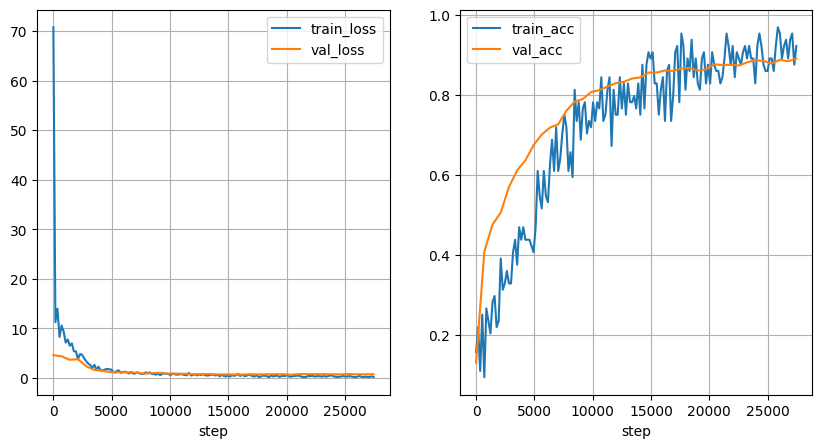

In [21]:
# 注意：训练损失是逐 batch 计算的（未平滑到 1 以下），验证损失则是全验证集均值
sample_step=eval_step//2
def plot_learning_curves(record_dict, sample_step=500):
    """
    可视化训练过程中的损失与准确率曲线。

    参数:
        record_dict (dict) : training() 函数返回的记录字典，
                             包含 'train' 和 'val' 两个键
        sample_step (int)  : 训练曲线的下采样间隔，避免点过多影响可读性，默认 500
    """
    # 将训练/验证记录列表转为 DataFrame，并以 step 为行索引
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    # 训练记录按 sample_step 步间隔抽样，减少绘图点数
    val_df   = pd.DataFrame(record_dict["val"]).set_index("step")
    # 验证记录较少，无需抽样，全部绘制

    fig_num = len(train_df.columns)  # 列数即指标数（通常为 loss 和 acc 两项）
    # 创建 1 行 fig_num 列的子图网格，每个子图宽 5 英寸、高 5 英寸
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for idx, item in enumerate(train_df.columns):  # 遍历每个指标列名
        # 绘制训练集曲线（步数为 X 轴，指标值为 Y 轴）
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        # 绘制验证集曲线
        axs[idx].plot(val_df.index,   val_df[item],   label=f"val_{item}")
        axs[idx].grid()    # 显示网格线，便于读取数值
        axs[idx].legend()  # 显示图例
        axs[idx].set_xlabel("step")  # X 轴标签

    plt.show()  # 渲染并显示图表

# 绘制学习曲线
plot_learning_curves(record, sample_step)

## 五、模型评估

加载训练过程中保存的最优检查点（`best.ckpt`），在验证集上计算最终的损失值与分类准确率。

In [22]:
# ===== 加载最优检查点并在验证集上评估 =====

# 从磁盘加载最佳模型权重（由 SaveCheckpointsCallback 保存的 best.ckpt）
# map_location='cpu'：即使训练时用 GPU，加载时先映射到 CPU，避免设备不匹配
model.load_state_dict(torch.load("model_checkpoints/5_model/5_model_best.ckpt", map_location="cpu"))

# 在验证集上计算平均损失与准确率
loss, acc = evaluating(model, eval_dl, loss_fct)
# 格式化打印评估结果（保留 4 位小数）
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")

loss:     0.7489
accuracy: 0.8904


## 六、模型预测（测试集推断）

使用训练好的最优模型对测试集全部图像进行推断，将预测类别写入 DataFrame，
最终保存为 `submission.csv` 供提交评测。

In [23]:
# ===== 测试集推断与结果收集 =====

# 创建测试集 Dataset 和 DataLoader
test_ds = Cifar10Dataset("test", transform=transforms_eval)  # 仅做尺寸调整与标准化
# drop_last=False：保留最后一个不足 batch_size 的批次，确保所有测试样本都被预测
test_dl = DataLoader(test_ds, batch_size=batch_size*2, shuffle=False, drop_last=False)

preds_collect = []  # 用于收集所有测试样本预测类别名称的列表
model.eval()  # 切换为评估模式
for data, fake_label in tqdm(test_dl):  # 遍历测试集；fake_label 为模板文件中的占位标签，不使用
    data   = data.to(device=device)  # 将测试图像批次移至目标设备
    logits = model(data)             # 前向传播，得到 logits，形状：[batch_size, num_classes]
    # 将 logits 最大值对应的整数索引转为类别名称字符串
    # logits.argmax(axis=-1)：得到每个样本的预测类别索引
    # idx_to_label[idx]：将索引映射回类别名称（如 'cat'）
    preds = [test_ds.idx_to_label[idx] for idx in logits.argmax(axis=-1).cpu().tolist()]
    preds_collect.extend(preds)  # 将本批次预测结果追加到总列表

# 将预测类别列表写入 test_df 的 'label' 列
test_df["label"] = preds_collect
test_df.head()  # 查看前 5 行，验证预测结果

100%|██████████| 2344/2344 [21:08<00:00,  1.85it/s]


,filepath,class,label
0,data\cifar-10\test\1.png,cat,cat
1,data\cifar-10\test\2.png,cat,airplane
2,data\cifar-10\test\3.png,cat,automobile
3,data\cifar-10\test\4.png,cat,ship
4,data\cifar-10\test\5.png,cat,airplane


### 6.1 保存预测结果至 CSV

将含预测标签列（`label`）的 `test_df` 导出为 `submission.csv`，用于比赛提交或后续分析。

In [24]:
# 将含预测标签的 test_df 保存为 submission.csv
# index=False：不将 DataFrame 行索引写入 CSV 文件
test_df.to_csv("submission.csv", index=False)